### 2026-02-06 time-mean biases

AIMIP evaluations of time-mean biases in the train (1979-2014, in-sample) and test (2015-2024, out of sample) periods.

In [12]:
import xarray as xr
import numpy as np
import os
import dataclasses
import dask
from typing import Literal

In [89]:
DATA_ROOT = '../local_data'
N_REALIZATIONS = 5

@dataclasses.dataclass
class EvaluationVariable:
    standard_name: str
    short_name: str
    long_name: str
    units: str

@dataclasses.dataclass
class ExperimentSubmission:
    submission_dir: str
    file_template: str
    experiment_name: str | None
    label: str | None
    data_root: str=DATA_ROOT

    def __post_init__(self):
        if self.label is None:
            self.label = ''
        if self.experiment_name is None:
            self.experiment_name = ''
        
    @property
    def name(self) -> str:
        return '/'.join([self.submission_dir, self.experiment_name])

    def get_variable_path(
        self,
        variable: "EvaluationVariable",
        i_r: int,
        table: str,
        grid: str
    ) -> str:
        file_format = self.file_template.format(
            i_r=i_r,
            table=table,
            varname=variable.short_name,
            grid=grid,
            label=self.label,
            experiment_name=self.experiment_name,
        )
        return os.path.join(
            self.data_root,
            self.submission_dir,
            self.experiment_name,
            file_format
        )
    

In [90]:
SECONDS_PER_DAY = 86400

FILE_TEMPLATES = {
    'Ai2': 
    'r{i_r}i1p1f1/{table}/{varname}/{grid}/{label}/{varname}_{table}_ACE2-ERA5_{experiment_name}_r{i_r}i1p1f1_{grid}_197810-202412.nc',
    'ArchesWeather':
    'r{i_r}i1p1f1/{table}/{varname}/{grid}/{varname}_{table}_ArchesWeather_{experiment_name}_r{i_r}i1p1f1_{grid}_197810-202501.nc',
    'ERA5_monthly_1deg': 'mon_1deg/native6_ERA5_an_v1_Amon_{varname}_1978-2024.nc'
}

EVALUATION_VARIABLES = [
    EvaluationVariable(
        standard_name='surface_precipitation',
        long_name='surface precipitation',
        short_name='pr',
        units='kg / s / m **2'
    ),
    EvaluationVariable(
        standard_name='surface_temperature',
        long_name='surface temperature',
        short_name='ts',
        units='K',
        
    ),
    EvaluationVariable(
        standard_name='air_temperature',
        long_name='air temperature',
        short_name='ta',
        units='K',
    ),
]

EXPERIMENT_SUBMISSIONS = [
    ExperimentSubmission(
        submission_dir='Ai2/ACE2-1-ERA5',
        experiment_name='aimip',
        file_template=FILE_TEMPLATES['Ai2'],
        label='v20251130'
    ),
    ExperimentSubmission(
        submission_dir='ArchesWeather/ArchesWeather-V2',
        experiment_name='aimip',
        file_template=FILE_TEMPLATES['ArchesWeather'],
        label=None
    ),
]

ERA5_1DEG = ExperimentSubmission(
    submission_dir='ERA5',
    file_template=FILE_TEMPLATES['ERA5_monthly_1deg'],
    experiment_name=None,
    label=None,
)

In [91]:
def open_aimip_data(
    experiment_submissions: list[ExperimentSubmission],
    evaluation_variables: list[EvaluationVariable],
    table: Literal['Amon', 'day'],
    grid: Literal['gn', 'gr'],
    n_realizations: int=N_REALIZATIONS,

) -> dict[str, xr.Dataset]:
    experiment_submission_datasets = {}
    for experiment_submission in experiment_submissions:
        print(experiment_submission.name)
        evaluation_variable_datasets = []
        for evaluation_variable in evaluation_variables:
            print(evaluation_variable.standard_name)
            realization_datasets = []
            for i_r in range(1, n_realizations + 1):
                variable_path = experiment_submission.get_variable_path(evaluation_variable, i_r, table, grid)
                
                try:
                    realization_dataset = xr.open_dataset(variable_path, chunks={})
                except FileNotFoundError:
                    print(f"Not found: {variable_path}")
                    realization_dataset = xr.Dataset()
                else:
                    print(variable_path)
                realization_datasets.append(realization_dataset.expand_dims({'realization': [i_r]}))
            evaluation_variable_dataset = xr.concat(realization_datasets, dim='realization')
            evaluation_variable_datasets.append(evaluation_variable_dataset)
        experiment_submission_dataset = xr.merge(evaluation_variable_datasets, compat='no_conflicts')
        experiment_submission_datasets[experiment_submission.name] =  experiment_submission_dataset
    return experiment_submission_datasets

In [92]:
monthly_data = open_aimip_data(
    EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
    grid='gn',
)

Ai2/ACE2-1-ERA5/aimip
surface_precipitation
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r4i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r5i1p1f1_gn_197810-202412.nc
surface_temperature
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_1

In [93]:
monthly_data['ArchesWeather/ArchesWeather-V2/aimip'].ta.isel(realization=0, time=0, lat=90, lon=180).compute()

<xarray.DataArray 'ta' (plev: 7)> Size: 28B
array([299.67328, 291.4176 , 283.13925, 268.2826 , 231.91049, 192.04271,
       207.37123], dtype=float32)
Coordinates:
    realization  int64 8B 1
    time         datetime64[ns] 8B 1978-10-16
    lon          float64 8B 180.0
    lat          float64 8B 0.0
  * plev         (plev) float64 56B 1e+05 8.5e+04 7e+04 ... 2.5e+04 1e+04 5e+03
Attributes:
    cell_methods:   time: mean
    standard_name:  air_temperature
    long_name:      Air Temperature
    comment:        Air Temperature
    units:          K
    cell_measures:  area: areacella
    history:        Processed for AIMIP

In [94]:
monthly_data['Ai2/ACE2-1-ERA5/aimip'].ta.isel(realization=0, time=0, lat=90, lon=180).compute()

<xarray.DataArray 'ta' (model_layer: 8)> Size: 32B
array([222.75102, 198.02873, 218.42458, 246.4641 , 267.7146 , 282.10516,
       291.0913 , 296.5817 ], dtype=float32)
Coordinates:
    realization  int64 8B 1
    lat          float32 4B 0.4986
    lon          float32 4B 180.5
    time         datetime64[ns] 8B 1978-10-01
  * model_layer  (model_layer) int64 64B 0 1 2 3 4 5 6 7
Attributes:
    units:          K
    long_name:      air temperature
    standard_name:  air_temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [95]:
era5_monthly_1deg = open_aimip_data(
    [ERA5_1DEG],
    EVALUATION_VARIABLES,
    table='Amon',
    grid='gn',
    n_realizations=1,
)

ERA5/
surface_precipitation
Not found: ../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_pr_1978-2024.nc
surface_temperature
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ts_1978-2024.nc
air_temperature
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ta_1978-2024.nc


/tmp/ipykernel_21295/2110596020.py:20: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  realization_dataset = xr.open_dataset(variable_path, chunks={})
/tmp/ipykernel_21295/2110596020.py:20: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's defaul

In [101]:
era5_monthly_1deg['ERA5/'].ta.isel(realization=0, time=0, lat=90, lon=180).compute()

<xarray.DataArray 'ta' (plev: 37)> Size: 148B
array([299.6635 , 297.5558 , 296.08765, 295.12796, 294.0531 , 292.95663,
       291.72147, 290.3969 , 289.02545, 287.62277, 286.19244, 283.1065 ,
       279.62808, 275.92532, 272.61578, 268.58362, 263.9745 , 258.51727,
       251.88994, 243.74649, 233.70842, 227.71556, 220.95604, 213.38892,
       205.12173, 196.50774, 189.26639, 193.60626, 207.01735, 215.86409,
       221.42163, 228.97125, 233.857  , 239.82553, 249.47923, 260.5315 ,
       264.60837], dtype=float32)
Coordinates:
    realization         int64 8B 1
    time                datetime64[ns] 8B 1978-01-17
    lat                 float64 8B 0.5
    lon                 float64 8B 180.5
    forecast_period     timedelta64[ns] 8B 00:00:00
    originating_centre  |S50 50B b'European Centre for Medium Range Weather F...
  * plev                (plev) float64 296B 1e+05 9.75e+04 ... 200.0 100.0
Attributes:
    standard_name:  air_temperature
    long_name:      Air Temperature
    units:          K
    GRIB_PARAM:     GRIBCode(edition=1, table_version=128, centre_number=98, ...
    cell_methods:   time: mean
    grid_mapping:   latitude_longitude

In [107]:
netcdf_files = []
for path, dirs, files in os.walk('/home/brianhenn/dev/AIMIP/local_data/ArchesWeather/ArchesWeather-V2/aimip-p4k/'):
    for file in files:
        if file.endswith('.nc'):
            netcdf_file = os.path.join(path, file)
            # print(netcdf_file)
            netcdf_files.append(netcdf_file)

In [108]:
len(netcdf_files)

120

In [81]:
len([file for file in netcdf_files if file.startswith('../local_data/ArchesWeather/ArchesWeatherGen-V2')])

463

In [91]:
len([file for file in netcdf_files if file.startswith('../local_data/ArchesWeather/ArchesWeather-V2/')])

420

In [83]:
len([file for file in netcdf_files if file.startswith('../local_data/Ai2/ACE2-1-ERA5')])

720

In [86]:
len([file for file in netcdf_files if file.startswith('../local_data/Google/NeuralGCM/')])

540

In [85]:
len([file for file in netcdf_files if file.startswith('../local_data/Google/NeuralGCM-HRD')])

540

In [87]:
len([file for file in netcdf_files if file.startswith('../local_data/NVIDIA/CMIP6/AIMIP/NVIDIA/cBottle-1-3/aimip')])

220

In [98]:
netcdf_files

['/home/brianhenn/dev/AIMIP/local_data/ArchesWeather/ArchesWeatherGen-V2/aimip-era5/aimip-p2k/r1i1p1f1/Amon/zg/gn/zg_Amon_ArchesWeatherGen_aimip-p2k_r1i1p1f1_gn_197810-202501.nc',
 '/home/brianhenn/dev/AIMIP/local_data/ArchesWeather/ArchesWeatherGen-V2/aimip-era5/aimip-p2k/r1i1p1f1/Amon/uas/gn/uas_Amon_ArchesWeatherGen_aimip-p2k_r1i1p1f1_gn_197810-202501.nc',
 '/home/brianhenn/dev/AIMIP/local_data/ArchesWeather/ArchesWeatherGen-V2/aimip-era5/aimip-p2k/r1i1p1f1/Amon/tas/gn/tas_Amon_ArchesWeatherGen_aimip-p2k_r1i1p1f1_gn_197810-202501.nc',
 '/home/brianhenn/dev/AIMIP/local_data/ArchesWeather/ArchesWeatherGen-V2/aimip-era5/aimip-p2k/r1i1p1f1/Amon/vas/gn/vas_Amon_ArchesWeatherGen_aimip-p2k_r1i1p1f1_gn_197810-202501.nc',
 '/home/brianhenn/dev/AIMIP/local_data/ArchesWeather/ArchesWeatherGen-V2/aimip-era5/aimip-p2k/r1i1p1f1/Amon/tos/gn/tos_Amon_ArchesWeatherGen_aimip-p2k_r1i1p1f1_gn_197810-202501.nc',
 '/home/brianhenn/dev/AIMIP/local_data/ArchesWeather/ArchesWeatherGen-V2/aimip-era5/aimip-p2

In [97]:
len([file for file in netcdf_files if file.startswith('../local_data/UMD-PARETO/MD-1p5/') and 'v20251217' in file])

0

ACE2.1-ERA5-aimip
surface_precipitation
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r4i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r5i1p1f1_gn_197810-202412.nc
surface_temperature
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_19781

In [37]:
time_mean_precip = datasets.squeeze().pr.mean('time')

In [49]:
with dask.diagnostics.ProgressBar():
    time_mean_precip = time_mean_precip.compute()

[########################################] | 100% Completed | 2.72 ss


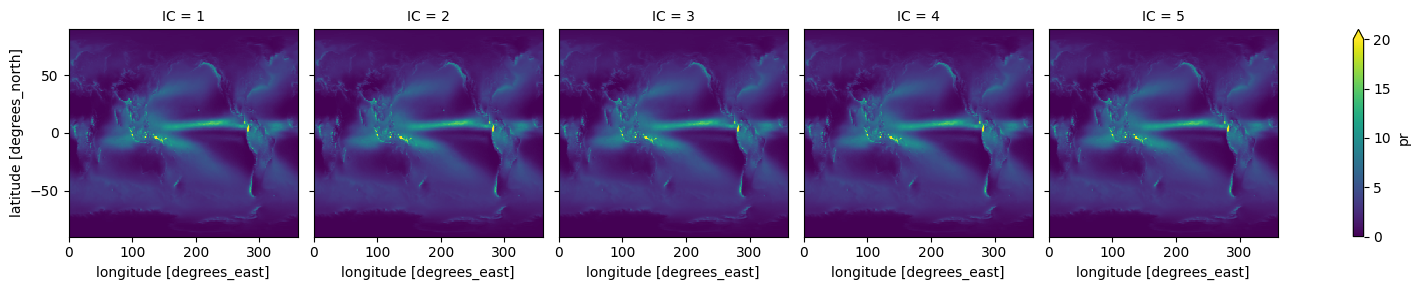

In [59]:
(SECONDS_PER_DAY * time_mean_precip).plot(col='IC', vmin=0, vmax=20)

In [111]:
path = '/home/brianhenn/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ta_1978-2024.nc'

In [112]:
ds = xr.open_dataset(path, chunks={})

/tmp/ipykernel_208086/4242964044.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(path, chunks={})


In [131]:
ds.time_bnds.isel(time=0).compute()

<xarray.DataArray 'time_bnds' (bnds: 2)> Size: 16B
array(['1978-01-01T12:00:00.000000000', '1978-02-01T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    time                datetime64[ns] 8B 1978-01-17
    forecast_period     timedelta64[ns] 8B 00:00:00
    originating_centre  |S50 50B b'European Centre for Medium Range Weather F...
Dimensions without coordinates: bnds